<a href="https://colab.research.google.com/github/io-uty/skt-bigdata-analysis/blob/main/07_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 5. 랜덤 포레스트 (Random Forest Classifier)

- 다수의 결정 트리를 생성하고 각 트리의 예측 결과를 취합하여 최종 정답을 도출하는 앙상블 (Ensemble)기반의 지도 학습 알고리즘
- 분류(Classification)와 회귀(Regression)문제 모두에 사용됨

- 결정트리를 수십 개에서 수백 개를 사용하는 배깅(Bagging) 방식을 적용한 알고리즘
- 배깅이란? 'Bootstrap Aggregating'의 약자
  - 원본 데이터에서 중복을 허용하여 여러 개의 샘플(부트스트랩)을 추출하고 각각의 샘플을 독립적으로 학습시킨 후, 그 결과들을 종합하여 예측 성능을 높이는 머신러닝 앙상블 기법

- 앙상블 알고리즘 중 비교적 수행 속도가 빠르고 다양한 영역에서 높은 예측 성능을 보인다.

> 앙상블(Ensemble)학습
- 앙상블은 프랑스어로 '전체적인 어울림', '조화', '함께'라는 뜻
- 여러 개의 개별 머신러닝 모델을 결합하여 단일 모델보다 훨씬 강력하고 정확한 최종 예측을 도출해내는 기법

- 보팅 (Voting)
  : 여러 개의 분류기가 투표를 통해 최종 예측 결과를 결정한다.
- 배깅 (Bagging)
  : 원본 데이터에서 Bootstrap으로 데이터를 샘플링을 한다. 분류기는 모두 같은 유형의 분류기를 사용한다.
- 부스팅 (Boosting)
  : 분류기가 순차적으로 학습을 수행한다.
  : 이진 분류기가 틀린 예측을 다음 분류기에서 올바르게 예측할 수 있도록 가중치 (weight) 를 부여하면서 학습과 예측을 진행한다.

- 데이터 준비

In [11]:
import pandas as pd

redwine = pd.read_csv('winequality-red.csv', sep=';')
whitewine = pd.read_csv('winequality-white.csv', sep=';')

df_redwine = pd.DataFrame(redwine)
df_whitewine = pd.DataFrame(whitewine)
df_redwine['type']='red'
df_whitewine['type'] = 'white'

df = pd.concat([df_redwine, df_whitewine])
df_redwine.head()
df_whitewine.head()
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,red
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,white
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,white
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,white
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,white


In [13]:
df.duplicated(keep='last') #중복일 시 마지막 데이터만 남김

,0
0,True
1,False
2,False
3,False
4,False
...,...
4893,False
4894,False
4895,False
4896,False


In [15]:
df = df[df.duplicated(keep='last')] #중복된 데이터 제거
df.shape #중복 데이터에서 마지막 한개 빼고 다 지움

(1177, 13)

In [16]:
df.type.value_counts()

,count
type,
white,937
red,240


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

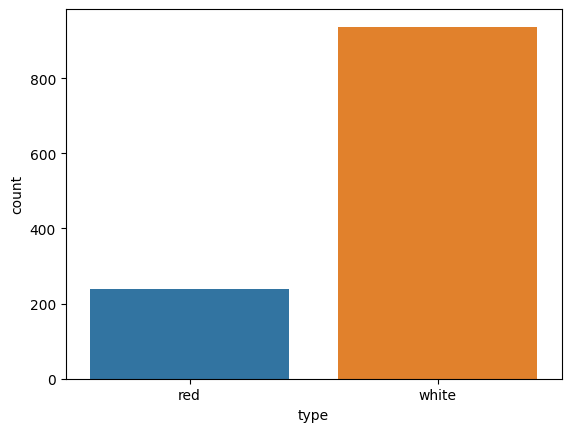

In [18]:
sns.countplot(x='type', data=df, hue='type')
plt.show()

- 레이블 인코딩
  : 연산을 ML, DL 연산 쉽게 하기 위해 문자를 숫자로

In [19]:
df['type'] = df["type"].copy().map({'red':0, 'white':1})
df.head()

/tmp/ipykernel_873/2003349621.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['type'] = df["type"].copy().map({'red':0, 'white':1})


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.700,0.00,1.90,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
9,7.5,0.500,0.36,6.10,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5,0
22,7.9,0.430,0.21,1.60,0.106,10.0,37.0,0.9966,3.17,0.91,9.5,5,0
39,7.3,0.450,0.36,5.90,0.074,12.0,87.0,0.9978,3.33,0.83,10.5,5,0
64,7.2,0.725,0.05,4.65,0.086,4.0,11.0,0.9962,3.41,0.39,10.9,5,0


- 피처와 label (type) 분리

In [22]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

X
y

,type
0,0
9,0
22,0
39,0
64,0
...,...
4825,1
4848,1
4849,1
4855,1


- 테스트 데이터 분리

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print('Train: ', X_train.shape, y_train.shape)
print("Test: ", X_test.shape, y_test.shape)

Train:  (823, 12) (823,)
Test:  (354, 12) (354,)


In [24]:
X_train = X_train.values
y_train = y_train.values
X_test = X_test.values
y_test = y_test.values

In [25]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_jobs=1, random_state=42)
clf.fit(X_train, y_train)

RandomForestClassifier(n_jobs=1, random_state=42)

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score

def print_score(y_true, y_pred):
  print('accuracy score: {0:.4f}',format(accuracy_score(y_true, y_pred)))
  print('precision score: {0:.4f}',format(precision_score(y_true, y_pred)))
  print('recall score: {0:.4f}',format(recall_score(y_true, y_pred)))

y_pred = clf.predict(X_test)
print_score(y_test, y_pred)

accuracy score: {0:.4f} 0.9971751412429378
precision score: {0:.4f} 0.9964539007092199
recall score: {0:.4f} 1.0


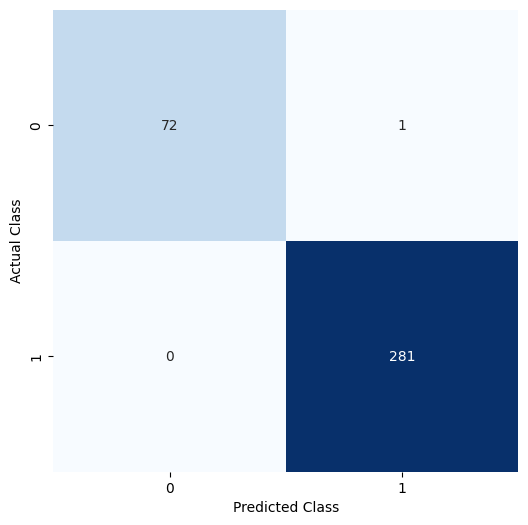

In [27]:
from sklearn.metrics import confusion_matrix

cfm = confusion_matrix(y_test, y_pred)
plt.figure(figsize = (6,6))

ax = sns.heatmap(cfm, annot=True, fmt='d',
                 cmap='Blues', cbar=False)

ax.set_ylabel('Actual Class')
ax.set_xlabel('Predicted Class')
plt.show()